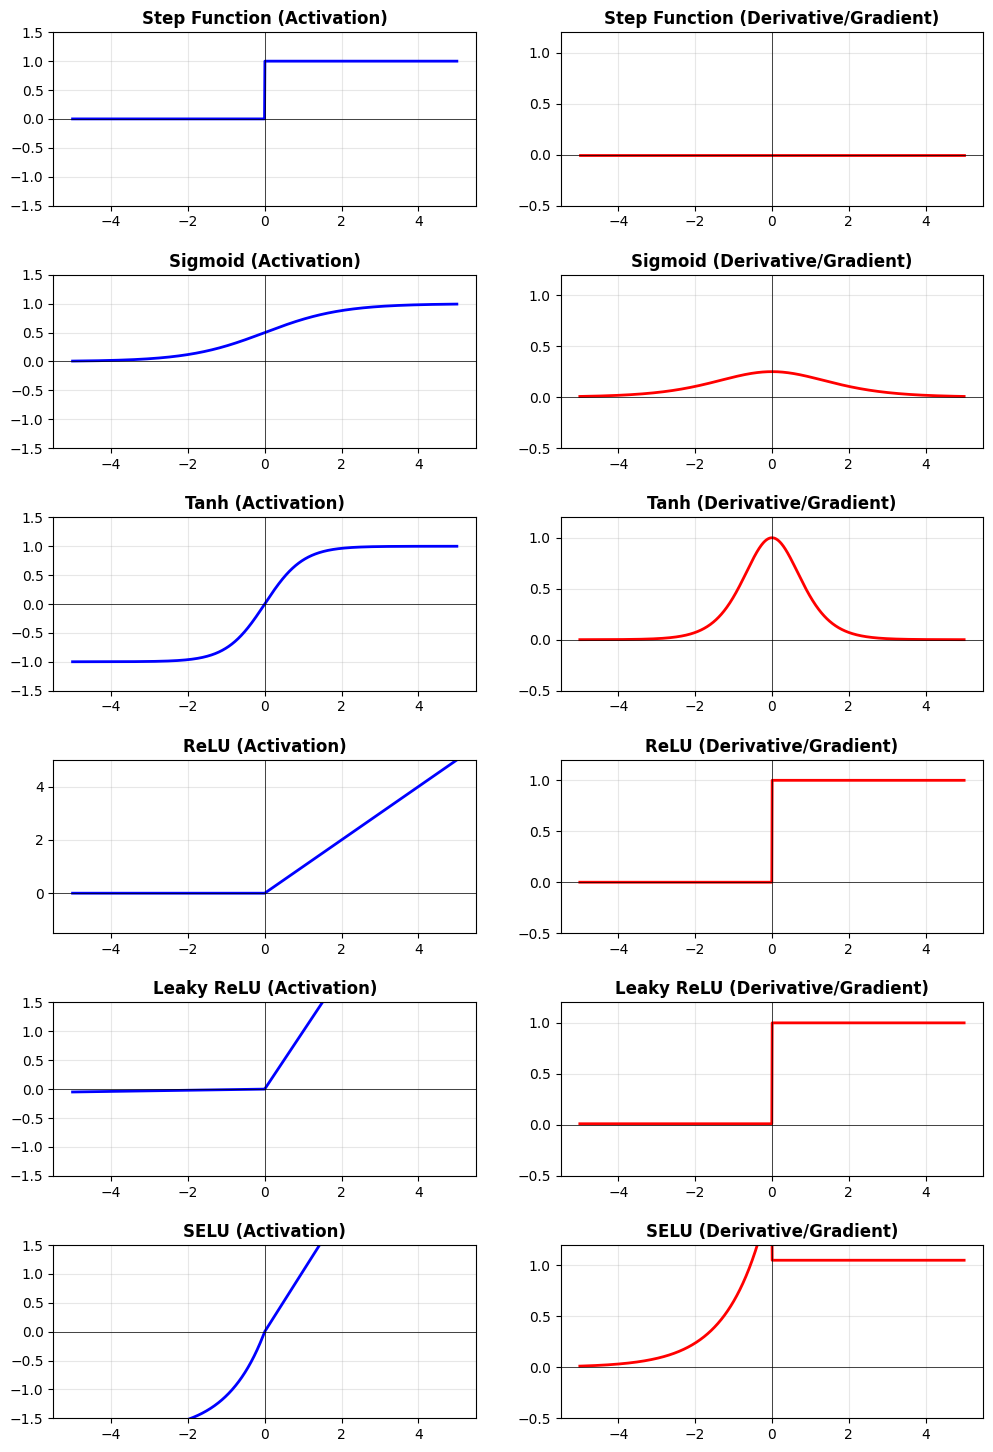

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Activation Functions
def step_function(z):
    return np.where(z > 0, 1, 0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def tanh(z):
    return np.tanh(z)

def relu(z):
    return np.maximum(0, z)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def selu(z, alpha=1.67326, scale=1.0507):
    return scale * np.where(z > 0, z, alpha * (np.exp(z) - 1))

# 2. Define Derivatives (Gradients)
def step_derivative(z):
    return np.zeros_like(z) # Everywhere 0 except jump (undefined)

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def tanh_derivative(z):
    return 1 - np.tanh(z) ** 2

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

def selu_derivative(z, alpha=1.67326, scale=1.0507):
    return scale * np.where(z > 0, 1, alpha * np.exp(z))

# 3. Generate Data
z = np.linspace(-5, 5, 1000)

# 4. Plotting
fig, axes = plt.subplots(6, 2, figsize=(12, 18))
plt.subplots_adjust(hspace=0.4)

functions = [
    ("Step Function", step_function, step_derivative),
    ("Sigmoid", sigmoid, sigmoid_derivative),
    ("Tanh", tanh, tanh_derivative),
    ("ReLU", relu, relu_derivative),
    ("Leaky ReLU", leaky_relu, leaky_relu_derivative),
    ("SELU", selu, selu_derivative)
]

for i, (name, func, deriv) in enumerate(functions):
    # Plot Activation
    axes[i, 0].plot(z, func(z), label=name, color='blue', linewidth=2)
    axes[i, 0].set_title(f"{name} (Activation)", fontsize=12, fontweight='bold')
    axes[i, 0].axhline(0, color='black', linewidth=0.5)
    axes[i, 0].axvline(0, color='black', linewidth=0.5)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].set_ylim(-1.5, 1.5 if name != "ReLU" else 5)

    # Plot Derivative
    axes[i, 1].plot(z, deriv(z), label=f"{name} Derivative", color='red', linewidth=2)
    axes[i, 1].set_title(f"{name} (Derivative/Gradient)", fontsize=12, fontweight='bold')
    axes[i, 1].axhline(0, color='black', linewidth=0.5)
    axes[i, 1].axvline(0, color='black', linewidth=0.5)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].set_ylim(-0.5, 1.2)

plt.show()